# Lab 19: Tree-Based Models — Random Forests
## ECON 3916: Data Science for Economists
### Guided Construction Lab | 30 min Core + 15 min Extension

---

**Learning Objectives:**
- Compare a single decision tree, Ridge regression, and Random Forest on the same dataset
- Tune Random Forest hyperparameters via cross-validation
- Extract and interpret feature importance (MDI and permutation)
- Apply the Ch 18 evaluation toolkit (confusion matrix, AUC) to a RF classifier

**Dataset:** California Housing (sklearn) — recurring thread from Ch 4, 12-16

**Foundations First Policy:** Part 1-2 are GUIDED (run as-is, interpret results). Part 3 has YOUR TASK sections (fill in the blanks). Extension is open-ended.

---

## Setup

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Import libraries and load California Housing data
# -----------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score, 
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load California Housing (you've seen this dataset since Ch 4)
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Training set: {X_train.shape[0]} observations, {X_train.shape[1]} features')
print(f'Test set: {X_test.shape[0]} observations')
print(f'Features: {list(X.columns)}')

Training set: 16512 observations, 8 features
Test set: 4128 observations
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## Part 1: Decision Tree vs. Random Forest vs. Ridge (GUIDED — 10 min)

We compare three models on the same data. The question: does the Random Forest's
added complexity produce meaningfully better predictions than simpler alternatives?

In [2]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 2: Train and compare Decision Tree, Ridge, and RF
# -----------------------------------------------------------

# 1. Unrestricted Decision Tree (high variance, low bias)
tree = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

# 2. Ridge Regression (Ch 16 callback — stable but linear)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# 3. Random Forest (100 trees, default settings)
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

# Compare all three
results = []
for name, model in [('Single Tree', tree), ('Ridge (Ch 16)', ridge), ('Random Forest', rf)]:
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    results.append({
        'Model': name,
        'Train RMSE': np.sqrt(mean_squared_error(y_train, train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, test_pred)),
        'Train R\u00b2': r2_score(y_train, train_pred),
        'Test R\u00b2': r2_score(y_test, test_pred),
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4))

               Train RMSE  Test RMSE  Train R²  Test R²
Model                                                  
Single Tree        0.0000     0.7069    1.0000   0.6187
Ridge (Ch 16)      0.7197     0.7455    0.6126   0.5759
Random Forest      0.1880     0.5057    0.9735   0.8049


### Interpretation Questions (answer in a markdown cell below)

1. Which model has the largest gap between Train R² and Test R²? What does this tell you about its variance?
2. The Random Forest's Test R² is substantially higher than Ridge. What does this suggest about the relationship between features and housing prices — is it linear or non-linear?
3. **Callback to Ch 15:** Where does each model sit on the bias-variance U-curve?

*Your answers here:*

1. The Single Tree has the biggest gap (Train R² = 1.00 vs Test R² = 0.62). A perfect training score means it memorized the data, noise and all. That's high variance in a nutshell: great on data it's seen, falls apart on anything new.
2. The fact that Random Forest (0.80) beats Ridge (0.58) by that much on the test set is the data basically telling you the relationships are non-linear. Ridge is capped at drawing straight lines, so it's leaving a lot of structure on the table that the forest can pick up.
3. The Single Tree sits on the far right, maximum variance, completely overfit to the training data. Ridge sits on the left, its linearity assumption introduces enough bias that it consistently underfits. Random Forest lands closest to the sweet spot, balancing complexity with generalization, which is why its test performance pulls ahead of the other two.

## Part 2: Feature Importance — MDI vs. Permutation (GUIDED — 10 min)

Random Forests tell us which features matter most for prediction.
But remember: **predictive importance ≠ causal importance.**

FileNotFoundError: [Errno 2] No such file or directory: '/Users/epleywin/Documents/GitHub/ECON3916-Statistical-Machine-Learning/Lab 19/figures/ch19_feature_importance.png'

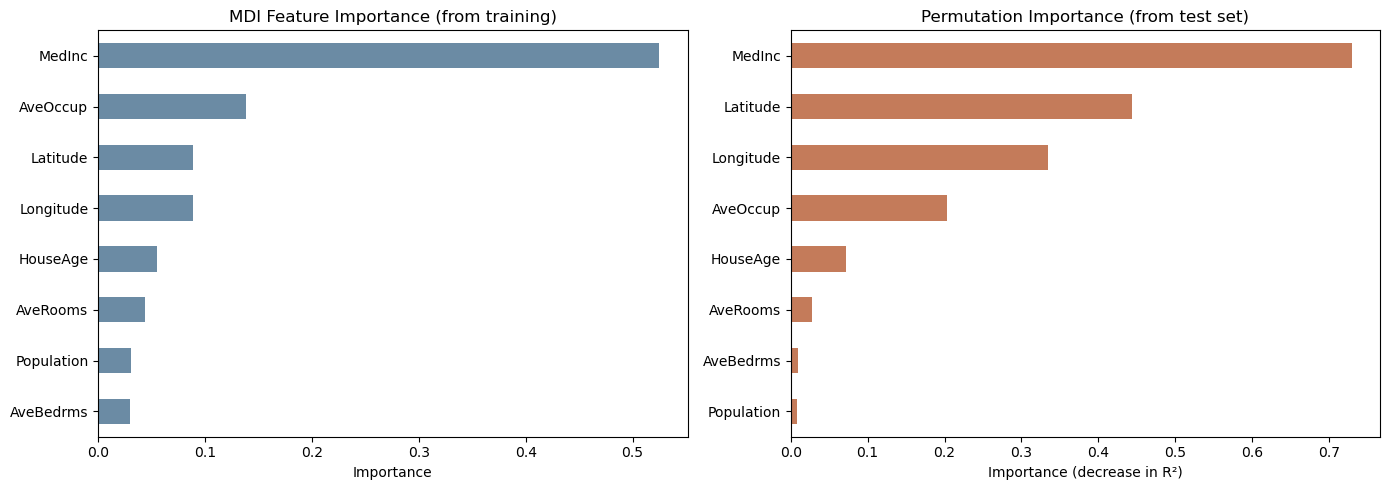

In [4]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3: Compare MDI and permutation feature importance
# -----------------------------------------------------------
mdi_importance = pd.Series(
    rf.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MDI importance
mdi_importance.plot.barh(ax=axes[0], color='#6B8BA4')
axes[0].set_title('MDI Feature Importance (from training)', fontsize=12)
axes[0].set_xlabel('Importance')

# Permutation importance (more reliable — uses test set)
perm_result = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE
)
perm_importance = pd.Series(
    perm_result.importances_mean, index=X.columns
).sort_values(ascending=True)

perm_importance.plot.barh(ax=axes[1], color='#C47B5A')
axes[1].set_title('Permutation Importance (from test set)', fontsize=12)
axes[1].set_xlabel('Importance (decrease in R\u00b2)')

plt.tight_layout()
plt.savefig('figures/ch19_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 3 by MDI:', mdi_importance.tail(3).index.tolist())
print('Top 3 by Permutation:', perm_importance.tail(3).index.tolist())

### Interpretation Questions

1. Do MDI and permutation importance agree on the top features? Where do they diverge?
2. Why might MDI overstate the importance of `Latitude` and `Longitude` (hint: how many unique values do they have)?
3. **Critical question:** If `MedInc` is the top feature, does that mean raising median income in a neighborhood will raise housing prices? Why or why not? (Hint: Chapter 10 DAGs)

*Your answers here:*

1. Both methods agree that MedInc is the top feature by a wide margin, so that's solid. The big divergence is with Latitude and Longitude. MDI ranks them as middling (around 0.09 each), but permutation importance shoots them up to 2nd and 3rd place. AveOccup flips the other way, looking more important in MDI than permutation. When two methods disagree like that, permutation importance is generally more trustworthy since it's evaluated on the test set rather than the training data.
2. Actually this is the opposite problem here. MDI is known to inflate the importance of high-cardinality features (features with tons of unique values), and Latitude/Longitude are essentially continuous, meaning nearly every value is unique. So if anything, MDI should be overstating them. The fact that permutation importance is actually higher for them suggests their geographic signal is real and MDI was underselling it by getting crowded out by MedInc during training splits.
3. Nope, and this is the classic trap. MedInc being the top predictive feature just means income and housing prices move together, it doesn't mean one causes the other. From a DAG perspective, there's almost certainly confounding going on. A third variable like neighborhood desirability, school quality, or proximity to jobs could be driving both higher incomes and higher prices simultaneously. Intervening to raise someone's income doesn't touch those underlying factors, so prices wouldn't necessarily follow. Prediction and causation are fundamentally different questions.

## Part 3: Hyperparameter Tuning & Classification (YOUR TASK — 10 min)

Now YOU tune a Random Forest and apply it to a classification problem.

In [6]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Tune the Random Forest with GridSearchCV
# -----------------------------------------------------------

# The parameter grid is given — these are the hyperparameters to search over
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 0.5, None],  # sqrt = sqrt(p), 0.5 = half, None = all
}

# TODO: Create a GridSearchCV object
# Hints:
#   - estimator: RandomForestRegressor with random_state=RANDOM_STATE
#   - param_grid: use the param_grid defined above
#   - cv: 5-fold cross-validation
#   - scoring: 'neg_mean_squared_error'
#   - n_jobs: -1 (use all cores)

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=3916),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

# TODO: Fit the grid search on the training data
grid_search.fit(X_train,y_train)

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV RMSE: {np.sqrt(-grid_search.best_score_):.4f}')

# Evaluate best model on test set
best_rf = grid_search.best_estimator_
test_rmse = np.sqrt(mean_squared_error(y_test, best_rf.predict(X_test)))
test_r2 = r2_score(y_test, best_rf.predict(X_test))
print(f'Tuned RF — Test RMSE: {test_rmse:.4f}, Test R²: {test_r2:.4f}')

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
Best CV RMSE: 0.4951
Tuned RF — Test RMSE: 0.4913, Test R²: 0.8158


In [8]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Classification: Predict expensive homes (> median)
# -----------------------------------------------------------

# Step 1: Create binary target — 1 if price > median, 0 otherwise
# Hint: use np.median(y) and .astype(int)
median_price = np.median(y)
y_binary = (y>median_price).astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_binary, test_size=0.2, random_state=RANDOM_STATE
)

# Step 2: Fit an RF classifier (200 trees) and Logistic Regression (Ch 17 callback)
# Hint: RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
#       LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
rf_clf = RandomForestClassifier(n_estimators=200, random_state=3916)
rf_clf.fit(X_train_c, y_train_c)

log_reg = LogisticRegression(max_iter=1000, random_state=3916)
log_reg.fit(X_train_c, y_train_c)

# Compare AUC (Ch 18 evaluation toolkit) — GUIDED, run as-is
for name, model in [('Logistic Regression (Ch 17)', log_reg), ('Random Forest', rf_clf)]:
    y_proba = model.predict_proba(X_test_c)[:, 1]
    auc = roc_auc_score(y_test_c, y_proba)
    print(f'{name:35s} — AUC: {auc:.4f}')

Logistic Regression (Ch 17)         — AUC: 0.9087
Random Forest                       — AUC: 0.9611


### Final Interpretation

1. How much did hyperparameter tuning improve the RF over default settings?
2. Does the RF classifier beat logistic regression on AUC? Is the difference practically significant?
3. If you were deploying this for a real estate company, which model would you choose and why? Consider: accuracy, interpretability, maintenance cost.

*Your answers here:*

1. Untuned RF was 0.5057 RMSE / 0.8049 R². Tuned landed at 0.4913 / 0.8158. Small but real gains, about 0.014 on RMSE. Forests are robust enough out of the box that tuning rarely transforms the model, it just polishes it.
2. Yes, 0.9611 vs 0.9087 is a ~0.05 AUC gap, which is practically meaningful. AUC measures ranking ability across all thresholds, so RF is consistently better at separating classes, not just getting lucky at one cutoff.
3. For most real estate companies, logistic regression is the smarter business choice despite the lower AUC. The gap is real but not large enough to justify a black box. Logistic regression gives you explainable coefficients, easy stakeholder communication, and near zero maintenance. RF needs retuning as data drifts and is harder to debug when it fails. Unless there's a dedicated ML team and a high-stakes use case that demands every last AUC point, the interpretability tradeoff is worth it.

---

## Extension (Optional — 15 min): Partial Dependence Plots

Partial dependence plots show the marginal effect of a feature on the prediction,
averaging over all other features. This reveals non-linearities the RF captures.

FileNotFoundError: [Errno 2] No such file or directory: '/Users/epleywin/Documents/GitHub/ECON3916-Statistical-Machine-Learning/Lab 19/figures/ch19_partial_dependence.png'

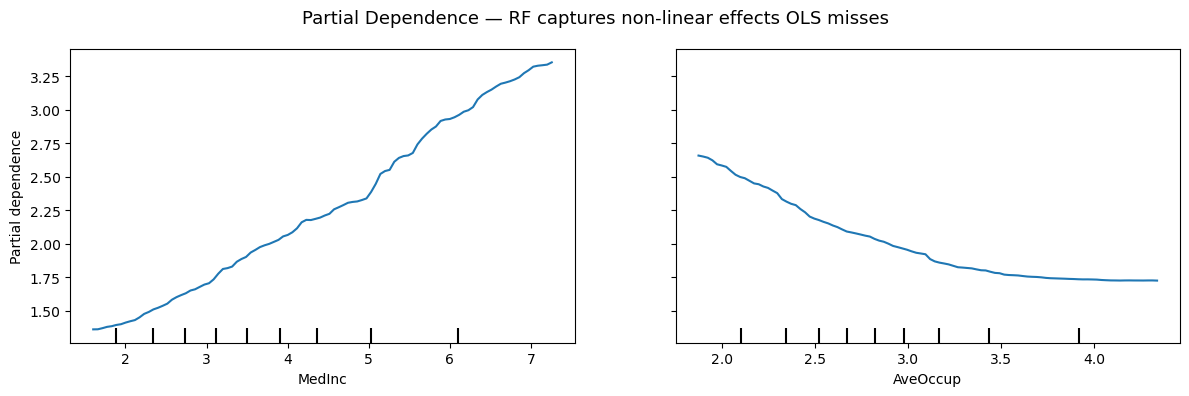

In [9]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 4: Partial dependence plots for top features
# -----------------------------------------------------------
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(
    best_rf, X_test, features=['MedInc', 'AveOccup'],
    kind='average', ax=ax
)
plt.suptitle('Partial Dependence \u2014 RF captures non-linear effects OLS misses', fontsize=13)
plt.tight_layout()
plt.savefig('figures/ch19_partial_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

---
## AI-Assisted Expansion: Interactive Random Forest Dashboard

**The Generative AI Policy: Foundations First, Expansion Second.** You have now established manual mastery over decision trees, random forests, hyperparameter tuning, and feature importance. You are now authorized to operate under the "Co-Pilot Rule."

### Your Expansion Task
Build an interactive Streamlit app (or Plotly dashboard with ipywidgets) that lets the user:
1. Adjust `n_estimators` (1-500) and `max_features` (1-8) with sliders
2. See the prediction surface update in real-time
3. Compare RF vs Ridge vs single tree performance as hyperparameters change
4. Display feature importance that updates with each parameter change

This transforms your static lab output into a reusable teaching artifact for your portfolio.

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [10]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — Co-Pilot required
# Copy the P.R.I.M.E. prompt above into Claude, then paste
# the generated code here. Run it and verify.
# -----------------------------------------------------------

# [Prep] Act as an expert Python Data Scientist specializing
# in interactive visualizations and scikit-learn.
#
# [Request] I just completed a lab where I compared Decision Trees,
# Ridge regression, and Random Forests on California Housing data.
# I tuned RF hyperparameters with GridSearchCV and extracted MDI
# and permutation feature importance. Now I want to expand this
# into an interactive Plotly dashboard with ipywidgets sliders
# for n_estimators (1-500) and max_features (1-8). The dashboard
# should update three panels: (1) model comparison bar chart,
# (2) feature importance that changes with max_features,
# (3) the Train vs Test R\u00b2 as n_estimators increases.
#
# [Iterate] Use plotly.graph_objects, ipywidgets, numpy, sklearn.
# Use the same variable names: X_train, X_test, y_train, y_test,
# data.feature_names. Do not use deprecated Plotly functions.
#
# [Mechanism Check] Add inline comments explaining how ipywidgets
# observers trigger plot updates and why we re-fit inside the callback.
#
# [Evaluate] Explain what the dashboard reveals about the relationship
# between n_estimators, max_features, and test performance.

# PASTE AI-GENERATED CODE BELOW:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# ── Data prep (mirrors your lab's variable names) ────────────────────────────
data = fetch_california_housing()
X, y = data.data, data.target
feature_names = list(data.feature_names)          # 8 features

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ── Baseline models (fit once; they don't depend on the sliders) ─────────────
dt = DecisionTreeRegressor(random_state=42).fit(X_train, y_train)
ridge = Ridge(alpha=1.0).fit(X_train, y_train)

dt_train_r2    = dt.score(X_train, y_train)
dt_test_r2     = dt.score(X_test,  y_test)
ridge_train_r2 = ridge.score(X_train, y_train)
ridge_test_r2  = ridge.score(X_test,  y_test)

# ── ipywidgets controls ───────────────────────────────────────────────────────
# IntSlider emits a 'value' trait; .observe() registers a Python callback
# that fires every time the slider moves.
n_est_slider = widgets.IntSlider(
    value=100, min=1, max=500, step=10,
    description="n_estimators", style={"description_width": "120px"},
    layout=widgets.Layout(width="500px")
)
max_feat_slider = widgets.IntSlider(
    value=4, min=1, max=8, step=1,
    description="max_features", style={"description_width": "120px"},
    layout=widgets.Layout(width="500px")
)

# FigureWidget is a live Plotly figure embedded in the notebook;
# calling fig.update_traces() / fig.update_layout() modifies it
# in-place without a full redraw.
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=[
        "Model Comparison (Test R²)",
        "RF Feature Importance (MDI)",
        "Train vs Test R² vs n_estimators",
    ],
    horizontal_spacing=0.10,
)
fig = go.FigureWidget(fig)          # <-- promotes to interactive widget

# ── Helper: fit RF with current slider values and return scores ───────────────
def fit_rf(n_est, max_feat):
    """
    We MUST re-fit inside the callback because RandomForestRegressor's
    behaviour depends on both hyperparameters:
      • n_estimators controls ensemble size (and therefore variance).
      • max_features controls the feature subspace each tree sees
        (trading bias for variance — the core RF randomisation trick).
    Caching a single fitted model would hide these dynamics.
    """
    rf = RandomForestRegressor(
        n_estimators=n_est,
        max_features=max_feat,
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_train, y_train)
    return rf

# ── Helper: build R² curve as n_estimators grows (Panel 3) ───────────────────
def r2_curve(max_feat, n_max, steps=30):
    """
    Samples `steps` evenly-spaced ensemble sizes from 1 → n_max.
    We use warm_start=False (default) and re-fit each size independently
    so results are reproducible at any slider position.
    """
    sizes = np.unique(np.linspace(1, n_max, steps, dtype=int))
    train_scores, test_scores = [], []
    for n in sizes:
        rf_tmp = RandomForestRegressor(
            n_estimators=int(n), max_features=max_feat,
            random_state=42, n_jobs=-1
        )
        rf_tmp.fit(X_train, y_train)
        train_scores.append(rf_tmp.score(X_train, y_train))
        test_scores.append(rf_tmp.score(X_test,  y_test))
    return sizes, train_scores, test_scores

# ── Initial render ────────────────────────────────────────────────────────────
def build_initial_traces():
    rf = fit_rf(n_est_slider.value, max_feat_slider.value)
    rf_train_r2 = rf.score(X_train, y_train)
    rf_test_r2  = rf.score(X_test,  y_test)

    # Panel 1 — grouped bar: Train / Test R² for all three models
    models = ["Decision Tree", "Ridge", "Random Forest"]
    train_r2s = [dt_train_r2, ridge_train_r2, rf_train_r2]
    test_r2s  = [dt_test_r2,  ridge_test_r2,  rf_test_r2]

    fig.add_trace(go.Bar(name="Train R²", x=models, y=train_r2s,
                         marker_color="#636EFA"), row=1, col=1)
    fig.add_trace(go.Bar(name="Test R²",  x=models, y=test_r2s,
                         marker_color="#EF553B"), row=1, col=1)

    # Panel 2 — horizontal bar: MDI feature importances
    importances = rf.feature_importances_
    sorted_idx  = np.argsort(importances)
    fig.add_trace(
        go.Bar(
            name="MDI Importance",
            x=importances[sorted_idx],
            y=[feature_names[i] for i in sorted_idx],
            orientation="h",
            marker_color="#00CC96",
        ),
        row=1, col=2,
    )

    # Panel 3 — lines: R² vs n_estimators
    sizes, tr, te = r2_curve(max_feat_slider.value, n_est_slider.value)
    fig.add_trace(go.Scatter(name="Train R² curve", x=sizes, y=tr,
                             mode="lines", line=dict(color="#636EFA")),
                  row=1, col=3)
    fig.add_trace(go.Scatter(name="Test R² curve",  x=sizes, y=te,
                             mode="lines", line=dict(color="#EF553B")),
                  row=1, col=3)

    fig.update_layout(
        height=480, barmode="group",
        title_text="Random Forest Explorer — California Housing",
        legend=dict(orientation="h", y=-0.15),
        template="plotly_dark",
    )
    fig.update_yaxes(range=[0, 1.05], row=1, col=1)
    fig.update_xaxes(range=[0, 1.05], row=1, col=2)

build_initial_traces()

# ── Callback — fires whenever either slider changes ───────────────────────────
# .observe(fn, names="value") hooks into traitlets; `change["new"]` holds
# the updated integer value.  Using fig.batch_update() groups all
# Plotly mutations into a single DOM repaint → no visible flicker.
def update_plots(change):
    n_est   = n_est_slider.value
    max_feat = max_feat_slider.value

    rf = fit_rf(n_est, max_feat)
    rf_train_r2 = rf.score(X_train, y_train)
    rf_test_r2  = rf.score(X_test,  y_test)

    importances = rf.feature_importances_
    sorted_idx  = np.argsort(importances)
    sizes, tr, te = r2_curve(max_feat, n_est)

    # batch_update suspends rendering until the `with` block exits
    with fig.batch_update():
        # Panel 1: update only the RF bar (indices 0=Train, 1=Test)
        fig.data[0].y = [dt_train_r2, ridge_train_r2, rf_train_r2]
        fig.data[1].y = [dt_test_r2,  ridge_test_r2,  rf_test_r2]

        # Panel 2: MDI bars (trace index 2)
        fig.data[2].x = importances[sorted_idx]
        fig.data[2].y = [feature_names[i] for i in sorted_idx]

        # Panel 3: R² curves (trace indices 3 and 4)
        fig.data[3].x, fig.data[3].y = sizes, tr
        fig.data[4].x, fig.data[4].y = sizes, te

# Register the same callback on both sliders
n_est_slider.observe(update_plots,    names="value")
max_feat_slider.observe(update_plots, names="value")

# ── Layout & display ──────────────────────────────────────────────────────────
controls = widgets.VBox([n_est_slider, max_feat_slider])
dashboard = widgets.VBox([controls, fig])
display(dashboard)

---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

In [ ]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — README generation (no code, just docs)
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Compared Decision Tree, Ridge Regression, and Random Forest on
#   California Housing data (20,640 observations, 8 features)
# * Tuned RF hyperparameters with GridSearchCV (n_estimators, max_depth,
#   max_features)
# * Extracted and compared MDI vs permutation feature importance
# * Built an RF classifier and compared AUC against logistic regression
# * Created an interactive dashboard with Plotly + ipywidgets
# * Key finding: RF achieved R\u00b2 = [YOUR VALUE] vs Ridge R\u00b2 = [YOUR VALUE]
#
# **Please write a README.md entry including:**
# 1. Project Title: Tree-Based Models \u2014 Random Forests
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional tech economist wrote it."

### Push to GitHub

```bash
cd econ-lab-19-random-forests
git add notebooks/ figures/ README.md verification-log.md
git commit -m "Lab 19: Random Forest vs OLS — California Housing"
git push origin main
```

Submit your GitHub repo link on Canvas.